# Détection des Zones d'Altération Hydrothermale

Ce notebook utilise les indices spectraux SWIR et le modèle Prithvi pour cartographier les zones d'altération (argiles, oxydes de fer).

## 1. Introduction et Contexte

Ce notebook explore l'utilisation de l'imagerie satellitaire Sentinel-2 et d'un modèle d'intelligence artificielle avancé, Prithvi EO v2, pour la détection et la cartographie des zones d'altération hydrothermale. L'altération hydrothermale est un processus géologique clé qui peut indiquer la présence de gisements minéraux.

Traditionnellement, la détection de ces zones est coûteuse et chronophage, nécessitant des levés de terrain et des analyses géochimiques. L'approche présentée ici vise à automatiser et à accélérer ce processus en combinant:

*   **Données Sentinel-2**: Imagerie multi-spectrale avec des bandes SWIR (Short-Wave Infrared) sensibles à la présence de minéraux argileux et hydroxylés, caractéristiques des zones d'altération.
*   **Modèle Prithvi EO v2**: Un modèle de fondation développé par la NASA et IBM, entraîné sur de vastes jeux de données d'observation de la Terre, capable d'extraire des caractéristiques sémantiques riches des images satellitaires.
*   **Indices Spectraux**: Calcul d'indices spécifiques (Clay, Iron, Ferrous, Kaolinite) pour accentuer les signatures spectrales des minéraux d'altération.
*   **Clustering (HDBSCAN)**: Regroupement non supervisé des signatures d'altération pour délimiter les zones d'intérêt.

L'objectif final est de générer une carte de potentiel d'exploration et un rapport synthétique, aidant ainsi les géologues à cibler leurs efforts sur le terrain de manière plus efficace.

## CELLULE 1: Initialisation et Préparation de l'Environnement

Cette cellule installe les bibliothèques nécessaires, initialise l'environnement Google Earth Engine et vérifie la disponibilité de CUDA pour PyTorch, ce qui est crucial pour l'accélération matérielle des calculs. Elle inclut également une gestion des erreurs pour l'authentification Earth Engine.

In [2]:
!pip install geemap earthengine-api rasterio terratorch torch matplotlib scikit-learn opencv-python -q
!pip install --upgrade --force-reinstall numpy scipy scikit-learn -q

import ee
import geemap
import torch
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler
from terratorch import BACKBONE_REGISTRY
import warnings
warnings.filterwarnings('ignore')

# Initialisation Earth Engine
try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize(project='geocongoai-api')  # Remplacez par votre projet

print("✅ Environnement prêt")
print(f"PyTorch CUDA: {torch.cuda.is_available()}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.
✅ Environnement prêt
PyTorch CUDA: False


## CELLULE 2: Définition de la zone d'étude (Congo)

In [3]:
# Coordonnées pour une zone potentiellement minéralisée
roi = ee.Geometry.Rectangle([15.0, -5.0, 16.0, -4.0])

# Carte interactive
Map = geemap.Map(basemap='Esri.WorldImagery')
Map.centerObject(roi, 8)
Map.addLayer(roi, {'color': 'red', 'width': 2}, 'Zone d\'étude')
Map

print(f"📍 Zone d'étude: {roi.getInfo()['coordinates']}")

📍 Zone d'étude: [[[15, -5], [16, -5], [16, -4], [15, -4], [15, -5]]]


Cette cellule définit la zone d'intérêt (Region of Interest - ROI) pour l'analyse en utilisant les coordonnées géographiques. Elle affiche également une carte interactive avec la zone d'étude en surbrillance rouge pour une visualisation facile.

In [9]:
## CELLULE 3: Acquisition des données Sentinel-2
def mask_clouds_s2(image):
    """Masque les nuages pour Sentinel-2"""
    qa = image.select('QA60')
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask)

# Collection Sentinel-2
collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filterBounds(roi)
              .filterDate('2023-01-01', '2024-12-31')
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
              .map(mask_clouds_s2))

# Image médiane
image = collection.median().clip(roi)

# Bandes pour Prithvi (Bleu, Vert, Rouge, NIR, SWIR1, SWIR2)
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
image_prithvi = image.select(bands)

# Export
geemap.ee_export_image(
    image_prithvi,
    'sentinel2_input.tif',
    scale=90, # Increased scale to reduce file size
    region=roi,
    file_per_band=False
)

print("✅ Image Sentinel-2 exportée")

Generating URL ...
Please wait ...
Data downloaded to /content/sentinel2_input.tif
✅ Image Sentinel-2 exportée


### Acquisition et Prétraitement des Données Sentinel-2

Ce bloc de code acquiert des images Sentinel-2 pour la zone et la période spécifiées. Il applique un masque de nuages pour garantir la qualité des données et sélectionne les bandes spectrales pertinentes pour le modèle Prithvi. L'image résultante est ensuite exportée en tant que fichier TIFF (`sentinel2_input.tif`) pour une utilisation hors ligne.

## 2. Méthodologie et Approche

L'approche adoptée dans ce notebook suit une chaîne de traitement en plusieurs étapes:

### 2.1. Initialisation de l'environnement
Installation et configuration des bibliothèques Python nécessaires (geemap, earthengine-api, terratorch, etc.) et initialisation de Google Earth Engine pour l'accès aux données satellitaires.

### 2.2. Définition de la Zone d'Intérêt (ROI)
Sélection d'une zone géographique spécifique pour l'analyse, généralement définie par des coordonnées. Cette étape est cruciale pour cibler l'acquisition des données.

### 2.3. Acquisition et Prétraitement des Données Sentinel-2
*   **Filtrage**: Récupération d'images Sentinel-2 pour la ROI sur une période donnée.
*   **Masquage des nuages**: Application d'un algorithme pour supprimer les pixels affectés par les nuages, assurant la qualité des données.
*   **Sélection des bandes**: Extraction des bandes spectrales pertinentes (Bleu, Vert, Rouge, Proche Infrarouge (NIR), Infrarouge à Ondes Courtes (SWIR1, SWIR2)) pour l'analyse.
*   **Export**: Exportation de l'image prétraitée au format GeoTIFF pour une manipulation locale.

### 2.4. Calcul des Indices Spectraux
Dérivation de plusieurs indices spectraux à partir des bandes Sentinel-2. Ces indices sont conçus pour mettre en évidence la présence de minéraux spécifiques associés à l'altération:
*   **Indice d'Argile (Clay)**: Sensible aux minéraux argileux (ex: illite, montmorillonite).
*   **Indice d'Oxyde de Fer (Iron)**: Sensible aux oxydes et hydroxydes de fer (ex: goethite, hématite).
*   **Indice Ferreux (Ferrous)**: Pour les minéraux ferreux.
*   **NDVI (Normalized Difference Vegetation Index)**: Utilisé pour évaluer la densité de la végétation et potentiellement masquer les zones de végétation dense qui pourraient masquer les signatures d'altération.
*   **Indice de Kaolinite**: Spécifique à la kaolinite, un minéral argileux souvent associé à l'altération acide.

### 2.5. Inférence du Modèle Prithvi EO v2
*   **Chargement du modèle**: Le modèle Prithvi EO v2 est chargé. Ce modèle, entraîné sur une vaste gamme de données d'observation de la Terre, est capable d'extraire des caractéristiques géospatiales complexes.
*   **Extraction des caractéristiques**: L'image Sentinel-2 est passée à travers le modèle Prithvi pour générer une carte de caractéristiques profondes. Ces caractéristiques représentent des patterns complexes et des relations spatiales dans l'image.

### 2.6. Clustering des Signatures d'Altération
*   **Préparation des données**: Les caractéristiques extraites par Prithvi sont aplaties et normalisées.
*   **HDBSCAN**: L'algorithme de clustering HDBSCAN est appliqué aux caractéristiques normalisées pour identifier des groupes (clusters) de pixels ayant des signatures spectrales et sémantiques similaires. HDBSCAN est choisi pour sa capacité à détecter des clusters de formes arbitraires et à gérer le bruit.
*   **Carte d'altération**: Les clusters identifiés sont transformés en une carte d'altération, où chaque cluster représente une zone d'altération potentielle.

### 2.7. Visualisation et Rapport
*   **Visualisation multi-panels**: Création d'une série de visualisations incluant l'image RGB, la carte d'altération, des superpositions, et les cartes d'indices spectraux.
*   **Carte de priorité d'exploration**: Génération d'une carte synthétique combinant les informations d'altération pour aider à prioriser les zones pour l'exploration sur le terrain.
*   **Rapport JSON**: Exportation d'un rapport structuré au format JSON résumant les statistiques clés pour chaque zone d'altération détectée (superficie, indices moyens, type d'altération).

## CELLULE 4: Calcul des indices spectraux d'altération

In [5]:
# Indices pour la détection des altérations hydrothermales
def compute_indices(image):
    indices = ee.Image.cat([
        # Indice d'argile (Alteration)
        image.expression('(B11 / B12)', {'B11': image.select('B11'), 'B12': image.select('B12')}).rename('Clay'),

        # Indice d'oxyde de fer (Iron Oxide)
        image.expression('(B4 / B2)', {'B4': image.select('B4'), 'B2': image.select('B2')}).rename('Iron'),

        # Indice de minéraux ferreux
        image.expression('(B12 / B8)', {'B12': image.select('B12'), 'B8': image.select('B8')}).rename('Ferrous'),

        # NDVI pour masquer la végétation dense
        image.normalizedDifference(['B8', 'B4']).rename('NDVI'),

        # Indice de kaolinite (altération acide)
        image.expression('(B11 + B7) / (B6 + B10)',
                        {'B11': image.select('B11'), 'B7': image.select('B7'),
                         'B6': image.select('B6'), 'B10': image.select('B10')}).rename('Kaolinite')
    ])
    return indices

indices = compute_indices(image)

print("✅ Indices spectraux calculés")

✅ Indices spectraux calculés


Ce bloc de code calcule plusieurs indices spectraux à partir des bandes Sentinel-2. Ces indices, tels que l'indice d'argile (Clay), l'indice d'oxyde de fer (Iron), l'indice ferreux (Ferrous), le NDVI (pour la végétation) et l'indice de kaolinite, sont essentiels pour identifier les signatures d'altération hydrothermale dans les roches.

## CELLULE 5: Chargement du modèle Prithvi

In [6]:
print("🚀 Chargement du modèle Prithvi EO v2...")

model = BACKBONE_REGISTRY.build(
    'prithvi_eo_v2_300',
    num_frames=1,
    in_chans=6,
    pretrained=True
)

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"✅ Modèle chargé sur {device}")

🚀 Chargement du modèle Prithvi EO v2...


Prithvi_EO_V2_300M.pt:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

✅ Modèle chargé sur cpu


Ce bloc charge le modèle de fondation pré-entraîné `Prithvi EO v2` de 300 millions de paramètres. Ce modèle est utilisé pour extraire des caractéristiques profondes de l'image satellite, qui serviront ensuite à la détection des zones d'altération. Le modèle est configuré pour s'exécuter sur le GPU (si disponible) pour des performances optimales.

## CELLULE 6: Inférence Prithvi + Extraction des altérations

In [10]:
print("📂 Lecture de l'image...")
with rasterio.open('sentinel2_input.tif') as src:
    img = src.read().astype(np.float32) / 10000.0
    profile = src.profile
    bounds = src.bounds

print(f"Image: {img.shape}")

# Inférence
input_tensor = torch.from_numpy(img).unsqueeze(0).to(device)

print("🔄 Inférence Prithvi...")
with torch.no_grad():
    output = model(input_tensor)
    features = output[0] if isinstance(output, list) else output

# Extraction des features sous forme de carte
if len(features.shape) == 3:
    n_tokens = features.shape[1]
    grid_size = int(np.sqrt(n_tokens - 1))
    feature_map = features[0, 1:].cpu().numpy().reshape(grid_size, grid_size, -1)
elif len(features.shape) == 4:
    # Assuming NCHW format for features
    feature_map = features[0].cpu().numpy().transpose(1, 2, 0) # Convert to HWC
else:
    raise ValueError("Unexpected feature map shape")

print(f"✅ Carte de caractéristiques: {feature_map.shape}")

📂 Lecture de l'image...
Image: (6, 496, 496)
🔄 Inférence Prithvi...
✅ Carte de caractéristiques: (31, 31, 1024)


Ce bloc de code lit l'image Sentinel-2 exportée, la prépare pour l'inférence du modèle Prithvi, puis exécute le modèle pour extraire des cartes de caractéristiques. Ces caractéristiques sont une représentation dense et abstraite des informations contenues dans l'image, cruciales pour la détection des altérations.

## CELLULE 7: Classification des zones d'altération

In [11]:
print("🔬 Clustering des signatures d'altération...")

# Préparation des données
h, w, d = feature_map.shape
features_flat = feature_map.reshape(-1, d)

# Normalisation
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_flat)

# HDBSCAN pour identifier les zones d'altération
clusterer = HDBSCAN(
    min_cluster_size=20,      # Taille minimale d'un cluster
    min_samples=5,            # Sensibilité au bruit
    metric='euclidean'
)

labels = clusterer.fit_predict(features_scaled)
alteration_map = labels.reshape(h, w)

n_clusters = len(np.unique(labels[labels >= 0]))
print(f"✅ {n_clusters} zones d'altération identifiées")

🔬 Clustering des signatures d'altération...
✅ 2 zones d'altération identifiées


Cette cellule utilise l'algorithme de clustering HDBSCAN pour regrouper les caractéristiques extraites par Prithvi. HDBSCAN est robuste aux bruits et permet d'identifier des clusters de formes arbitraires, ce qui est idéal pour délimiter les zones d'altération. Les clusters identifiés sont ensuite transformés en une carte d'altération.

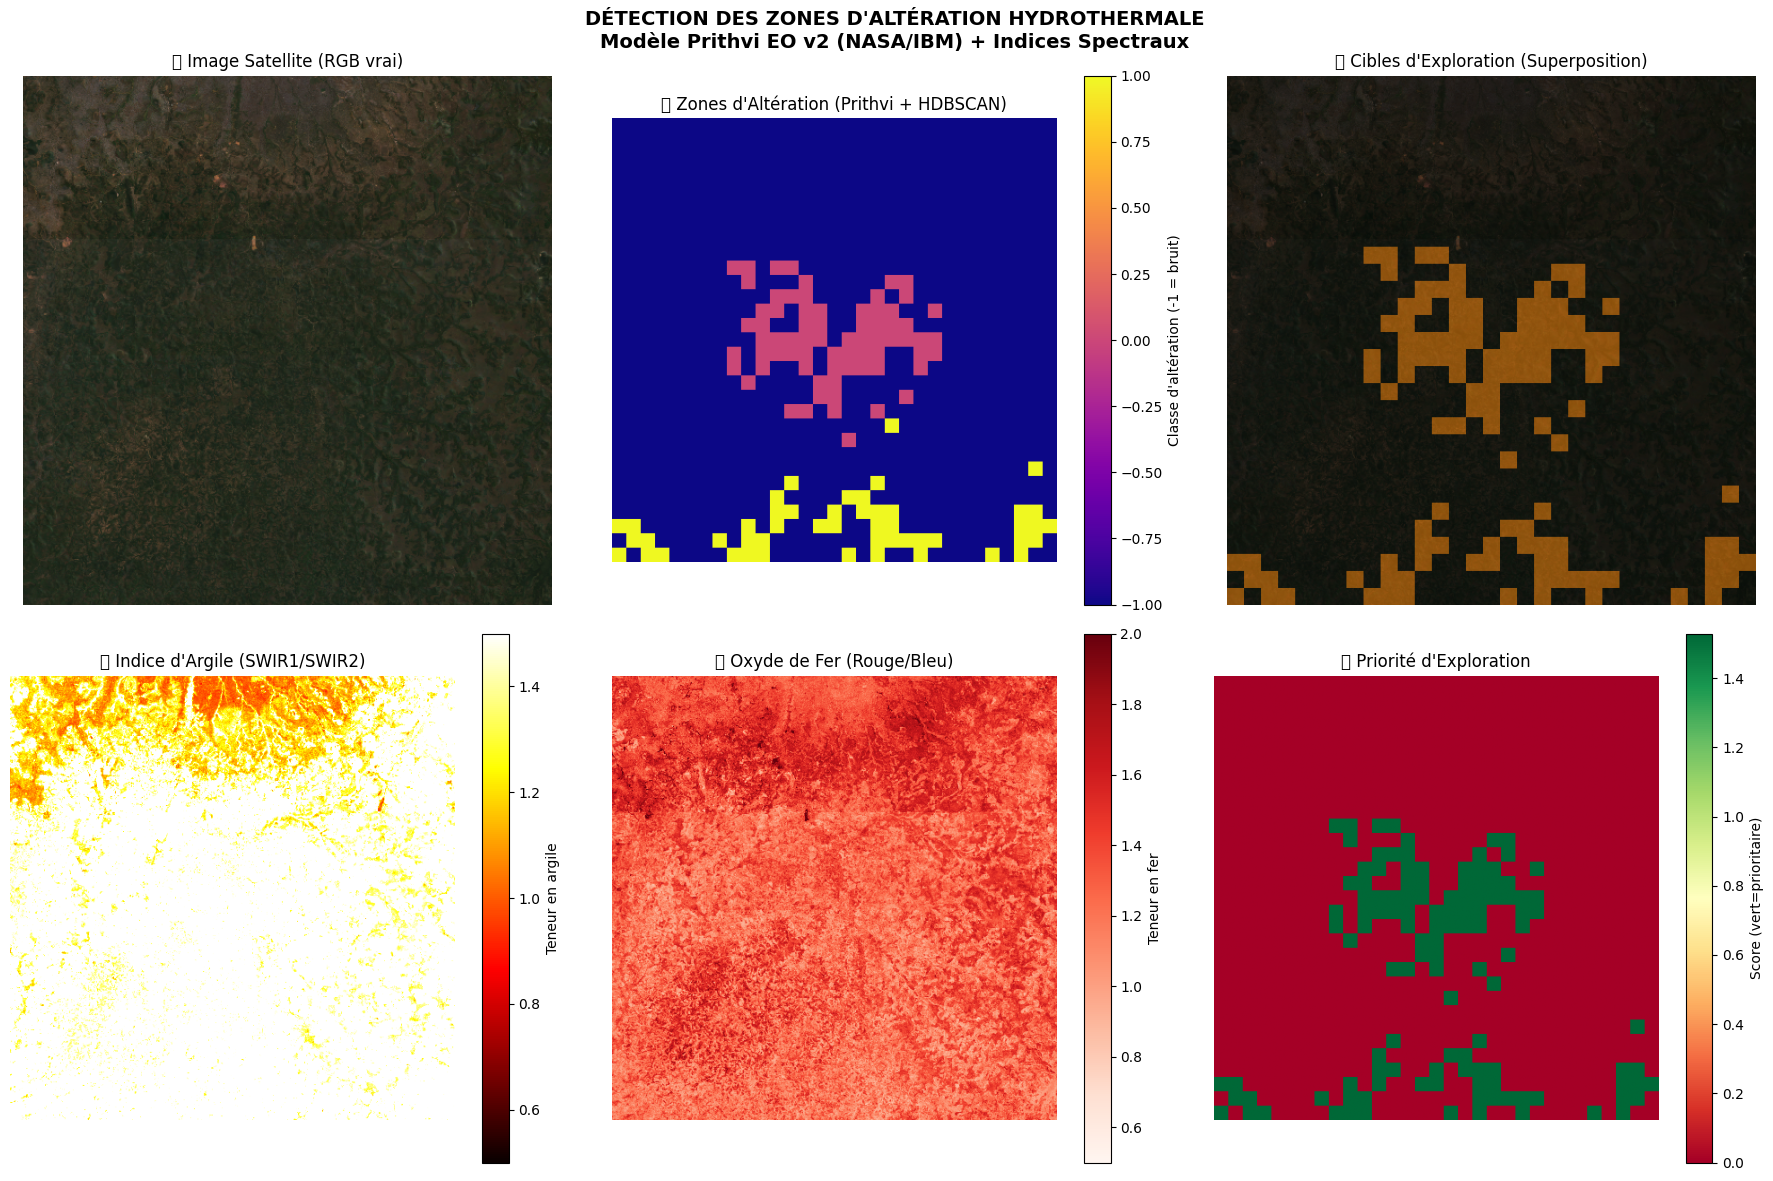

In [18]:
## CELLULE 8: Visualisation multi-panels
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Get full image dimensions (H, W) from the original img
full_h, full_w = img.shape[1:]

# Import cv2 for image resizing
import cv2

# Upsample alteration_map to full image dimensions for consistent masking
# Use INTER_NEAREST for classification maps to avoid introducing new class values
upsampled_alteration_map = cv2.resize(alteration_map.astype(np.float32), (full_w, full_h), interpolation=cv2.INTER_NEAREST)
# Convert back to integer type as HDBSCAN labels are integers
upsampled_alteration_map = upsampled_alteration_map.astype(int)

# 1. Image RGB vraie
rgb = np.stack([img[2], img[1], img[0]], axis=-1)
rgb = np.clip(rgb * 2.5, 0, 1)
axes[0, 0].imshow(rgb)
axes[0, 0].set_title('📸 Image Satellite (RGB vrai)', fontsize=12)
axes[0, 0].axis('off')

# 2. Carte d'altération Prithvi
cmap_alter = LinearSegmentedColormap.from_list('alteration', ['darkblue', 'cyan', 'yellow', 'red'], N=256)
im = axes[0, 1].imshow(upsampled_alteration_map, cmap='plasma') # Use upsampled_alteration_map
axes[0, 1].set_title('🧠 Zones d\'Altération (Prithvi + HDBSCAN)', fontsize=12)
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1], label='Classe d\'altération (-1 = bruit)')

# 3. Superposition altération sur RGB
overlay = rgb.copy()
mask = upsampled_alteration_map != -1 # Use upsampled_alteration_map
overlay_alter = np.zeros_like(rgb)
overlay_alter[mask] = [1, 0.5, 0]  # Orange pour les altérations
alpha = 0.5
axes[0, 2].imshow(rgb)
axes[0, 2].imshow(overlay_alter, alpha=alpha)
axes[0, 2].set_title('🎯 Cibles d\'Exploration (Superposition)', fontsize=12)
axes[0, 2].axis('off')

# 4. Indice d'argile
clay_data = np.clip(img[4] / (img[5] + 0.001), 0, 2)  # SWIR1/SWIR2 (already full size)
axes[1, 0].imshow(clay_data, cmap='hot', vmin=0.5, vmax=1.5)
axes[1, 0].set_title('🏺 Indice d\'Argile (SWIR1/SWIR2)', fontsize=12)
axes[1, 0].axis('off')
plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], label='Teneur en argile')

# 5. Indice d'oxyde de fer
iron_data = np.clip(img[2] / (img[0] + 0.001), 0, 2)  # Rouge/Bleu (already full size)
axes[1, 1].imshow(iron_data, cmap='Reds', vmin=0.5, vmax=2.0)
axes[1, 1].set_title('🔴 Oxyde de Fer (Rouge/Bleu)', fontsize=12)
axes[1, 1].axis('off')
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], label='Teneur en fer')

# 6. Carte de priorité d'exploration
priority = np.zeros((full_h, full_w), dtype=float) # Initialize priority map with full dimensions
for i in range(n_clusters):
    # Use upsampled_alteration_map for masking clay_data and iron_data
    cluster_mask = upsampled_alteration_map == i
    if cluster_mask.sum() > 0:
        mean_clay = clay_data[cluster_mask].mean()
        mean_iron = iron_data[cluster_mask].mean()
        priority[cluster_mask] = (mean_clay + mean_iron) / 2

axes[1, 2].imshow(priority, cmap='RdYlGn')
axes[1, 2].set_title('⭐ Priorité d\'Exploration', fontsize=12)
axes[1, 2].axis('off')
plt.colorbar(axes[1, 2].images[0], ax=axes[1, 2], label='Score (vert=prioritaire)')

plt.suptitle('DÉTECTION DES ZONES D\'ALTÉRATION HYDROTHERMALE\nModèle Prithvi EO v2 (NASA/IBM) + Indices Spectraux',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## CELLULE 8: Visualisation multi-panels

Ce bloc de code génère une série de visualisations pour analyser les résultats. Il affiche l'image RGB originale, la carte d'altération détectée par Prithvi et HDBSCAN, une superposition de ces altérations sur l'image RGB, et les cartes d'indices d'argile et d'oxyde de fer. Une carte de priorité d'exploration est également créée, combinant les indices d'altération pour aider à identifier les zones les plus prometteuses.

## CELLULE 9: Statistiques et rapport des cibles

In [22]:
print("="*70)
print("📊 RAPPORT D'EXPLORATION MINIÈRE")
print("="*70)

# Statistiques par zone d'altération
for i in range(n_clusters):
    # Use upsampled_alteration_map for masking
    mask = upsampled_alteration_map == i
    area_pixels = mask.sum()
    area_km2 = area_pixels * (30 * 30) / 1_000_000  # Résolution 30m

    # Extraction des indices moyens
    mean_clay = clay_data[mask].mean() if np.any(mask) else 0
    mean_iron = iron_data[mask].mean() if np.any(mask) else 0

    # Classification du type d'altération
    if mean_clay > 1.2:
        alteration_type = "🟡 Altération argileuse intense"
    elif mean_clay > 0.9:
        alteration_type = "🟠 Altération argileuse modérée"
    elif mean_iron > 1.2:
        alteration_type = "🔴 Enrichissement en oxydes de fer"
    elif mean_iron > 0.9:
        alteration_type = "🟤 Oxydation ferrique"
    else:
        alteration_type = "⚪ Altération indéterminée"

    print(f"\n📌 CIBLE {i+1}:")
    print(f"   Superficie: {area_km2:.2f} km²")
    print(f"   Indice argile: {mean_clay:.2f}")
    print(f"   Indice fer: {mean_iron:.2f}")
    print(f"   Type: {alteration_type}")

# Cibles prioritaires
print("\n" + "="*70)
print("🎯 CIBLES D'EXPLORATION PRIORITAIRES")
print("="*70)

📊 RAPPORT D'EXPLORATION MINIÈRE

📌 CIBLE 1:
   Superficie: 16.36 km²
   Indice argile: 1.81
   Indice fer: 1.24
   Type: 🟡 Altération argileuse intense

📌 CIBLE 2:
   Superficie: 11.29 km²
   Indice argile: 1.86
   Indice fer: 1.20
   Type: 🟡 Altération argileuse intense

🎯 CIBLES D'EXPLORATION PRIORITAIRES


Cette cellule génère un rapport textuel détaillé des zones d'altération identifiées. Pour chaque cluster, elle calcule la superficie en km², les valeurs moyennes des indices d'argile et de fer, et classe le type d'altération (intense, modérée, enrichissement en oxydes, etc.). Ce rapport fournit un résumé quantitatif et qualitatif des découvertes.

## CELLULE 10: Export des résultats

In [25]:
from PIL import Image
import json
from datetime import datetime

# Sauvegarde de la carte d'altération
alteration_img = (upsampled_alteration_map / np.max(upsampled_alteration_map[upsampled_alteration_map >=0]) * 255).astype(np.uint8) # only scale non-noise clusters
Image.fromarray(alteration_img).save('carte_alteration.png')
print("💾 Sauvegardé: carte_alteration.png")

# Rapport JSON
report = {
    'date': datetime.now().isoformat(),
    'zone': {
        'lon_min': float(bounds.left),
        'lon_max': float(bounds.right),
        'lat_min': float(bounds.bottom),
        'lat_max': float(bounds.top)
    },
    'n_clusters': int(n_clusters),
    'resolution_m': 30,
    'modele': 'Prithvi_EO_v2_300',
    'indices': ['Clay', 'Iron', 'NDVI', 'Kaolinite'],
    'cibles': []
}

for i in range(n_clusters):
    mask = upsampled_alteration_map == i # Use upsampled_alteration_map here
    report['cibles'].append({
        'id': i+1,
        'pixels': int(mask.sum()),
        'superficie_km2': float(mask.sum() * 30 * 30 / 1_000_000),
        'clay_index': float(clay_data[mask].mean()) if np.any(mask) else 0,
        'iron_index': float(iron_data[mask].mean()) if np.any(mask) else 0
    })

with open('rapport_alteration.json', 'w') as f:
    json.dump(report, f, indent=2)
print("💾 Sauvegardé: rapport_alteration.json")

print("\n✅ Analyse terminée avec succès!")

💾 Sauvegardé: carte_alteration.png
💾 Sauvegardé: rapport_alteration.json

✅ Analyse terminée avec succès!


Ce dernier bloc de code exporte les résultats finaux. Il sauvegarde la carte d'altération sous forme de fichier PNG et génère un rapport complet au format JSON, incluant toutes les statistiques et informations pertinentes sur les cibles d'exploration. Ces fichiers peuvent être utilisés pour une analyse ultérieure ou pour être intégrés dans d'autres systèmes SIG.